In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv("height-weight.csv")

In [82]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [83]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [84]:
df.tail()

,Weight,Height
18,76,150
19,87,167
20,45,129
21,56,140
22,72,160


In [85]:
df.shape

(23, 2)

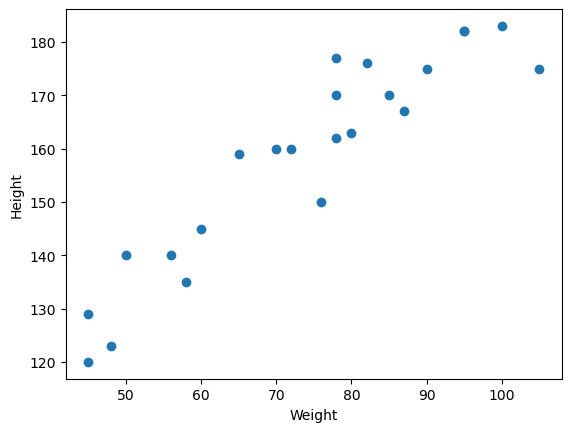

In [86]:
plt.scatter(df.Weight, df.Height)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [87]:
# Probel >> I want to predict height based on weight

In [88]:
# Divide the data into x and y
X = df[["Weight"]]
y = df[["Height"]]

In [89]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [90]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [91]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)

In [92]:
X_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [93]:
X_test

,Weight
20,45
17,65
3,60
13,100
19,87
16,50


In [94]:
y_train

,Height
10,176
4,160
2,123
18,150
6,163
7,175
1,135
14,170
0,120
15,177


In [95]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [96]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((17, 1), (17, 1), (6, 1), (6, 1))

In [97]:
# Scaling is Optional >> Standardization >> fit_transform on train data and transform on train data.
# If we use fit on test data i.e. wrong we are doing data leakage
# We fit only train data >> cause we want test data to remain unseen during training

In [98]:
from sklearn.preprocessing import StandardScaler

In [99]:
scaler = StandardScaler()

In [100]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [101]:
X_train

,Weight
10,82
4,70
2,48
18,76
6,80
7,90
1,58
14,85
0,45
15,78


In [102]:
# Scaling should be alwasy done after train test split
# Target variable should not be scaled
# Avoid scaling categorical features
X_train = scaler.fit_transform(X_train) # For train data we will use fit_transform
X_test = scaler.transform(X_test) # For test data we will use transform

In [103]:
X_train

array([[ 0.37554243],
       [-0.36825034],
       [-1.73187043],
       [ 0.00364604],
       [ 0.25157697],
       [ 0.87140428],
       [-1.11204312],
       [ 0.56149062],
       [-1.91781863],
       [ 0.12761151],
       [-0.24428488],
       [-1.23600858],
       [ 0.12761151],
       [ 1.18131794],
       [ 1.80114525],
       [ 1.18131794],
       [ 0.12761151]])

In [104]:
X_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

In [105]:
# Scaling is Optional >> Because it does not affect the distribution of the data
from sklearn.linear_model import LinearRegression

# LinearRegression parameters
# fit_intercept >> The best fit line will have intercept, by default it is true
# copy_X >> copy the original X_train and then build the model, it will not modify the original data
# in_job >> 1 means you want to use all the processors
# positive >> When the set is true >> forces the coefficient to be positive

# fit >> train the model
# predict >> test the model

# After building the model, you have attributes of the model
#corf_
# intercept

In [106]:
regressor = LinearRegression()

In [107]:
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
regressor.coef_

array([[17.7307072]])

In [109]:
regressor.intercept_

array([160.])

In [110]:
print("The slope or coefficient of the model is",regressor.coef_)

The slope or coefficient of the model is [[17.7307072]]


In [111]:
print("The intercept of the model is", regressor.intercept_)

The intercept of the model is [160.]


In [112]:
#Prediction on test data
# Interpretation of coef_ >> one unit increase in weight will increase on an average the height by 17.73 units
# Predicted height(y) = 160 + 17.73 * (X_test)

In [113]:
# Prediction on train data
regressor.predict(X_train)

array([[166.65863288],
       [153.47066096],
       [129.29271243],
       [160.06464692],
       [164.46063756],
       [175.45061417],
       [140.28268904],
       [169.95562586],
       [125.99571945],
       [162.26264224],
       [155.66865628],
       [138.08469371],
       [162.26264224],
       [180.94560247],
       [191.93557907],
       [180.94560247],
       [162.26264224]])

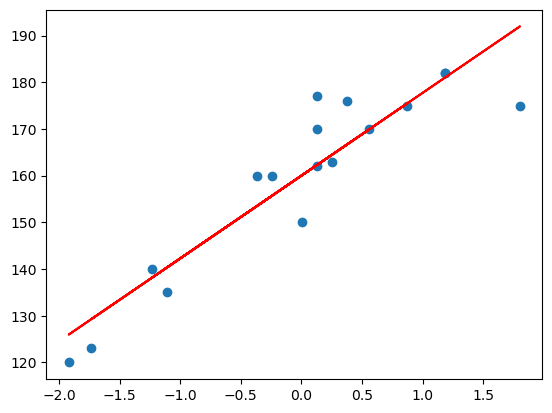

In [114]:
plt.scatter(X_train, y_train)
plt.plot(X_train,regressor.predict(X_train), color = 'red')

In [115]:
y_pred_test = regressor.predict(X_test)
y_pred_test

array([[125.99571945],
       [147.97567266],
       [142.48068436],
       [186.44059077],
       [172.15362118],
       [131.49070775]])

In [116]:
y_pred_test,  y_test

(array([[125.99571945],
        [147.97567266],
        [142.48068436],
        [186.44059077],
        [172.15362118],
        [131.49070775]]),
     Height
 20     129
 17     159
 3      145
 13     183
 19     167
 16     140)

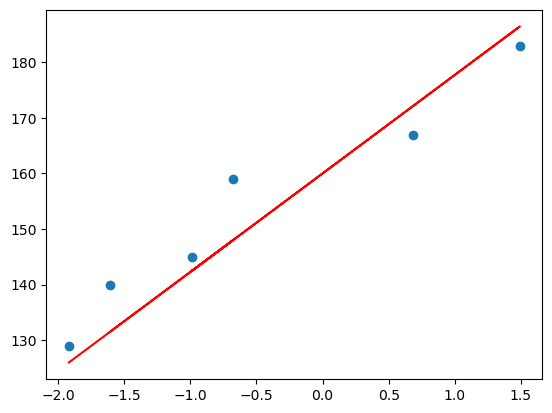

In [117]:
plt.scatter(X_test, y_test)
plt.plot(X_test,regressor.predict(X_test), color = 'red')

In [119]:
# Performane metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [120]:
mean_absolute_error(y_test, y_pred_test)

5.6085712893048365

In [121]:
mean_squared_error(y_test, y_pred_test)

41.2856628304555

In [125]:
r_sq = r2_score(y_test, y_pred_test)
r_sq

0.8721036174256606

In [123]:
# Adjusted R square
# Adjusted R2 = [1 - (1 - rsquare)*(n-1)/ (n-k-1)]
# n is number of observation and k is no of predictor variable

In [124]:
X_test.shape[0]

6

In [128]:
# Adjusted r square will always be lesser than r square
Adjusted_rsq = 1 - (1 - r_sq) * (len(y_test) - 1)/(len(y_test) - X_test.shape[1] - 1)
Adjusted_rsq

0.8401295217820757

In [129]:
# Assumptions 
# X-y should have linear relationship
# Observation should have no relation
# Error should have constant variation
# Error should be normally distributed
# features among themselves should be least related 

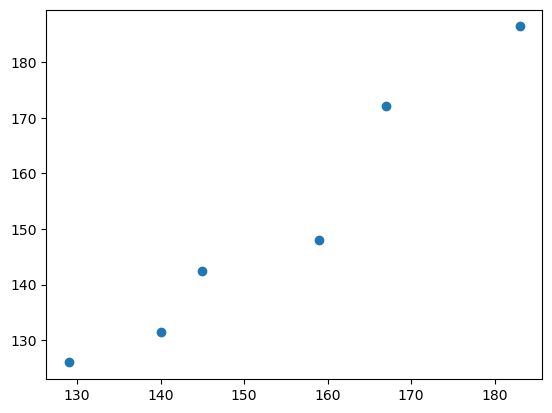

In [130]:
plt.scatter(y_test, y_pred_test)
# To check if y_test and its prediction aligns

In [131]:
error = y_test - y_pred_test
error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


In [132]:
import seaborn as sns

C:\Users\karti\AppData\Local\Temp\ipykernel_27376\3211213348.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error) # Approximately normal distribution


<Axes: ylabel='Density'>

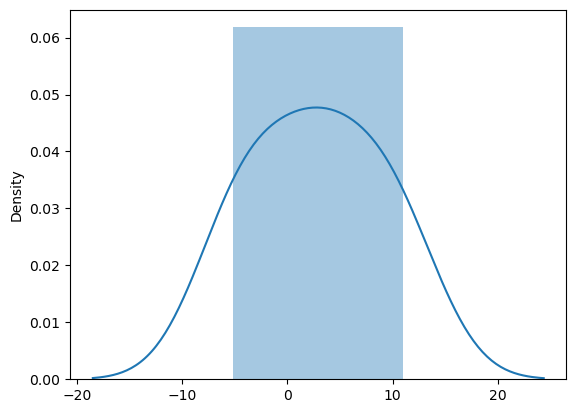

In [136]:
sns.distplot(error) # Approximately normal distribution

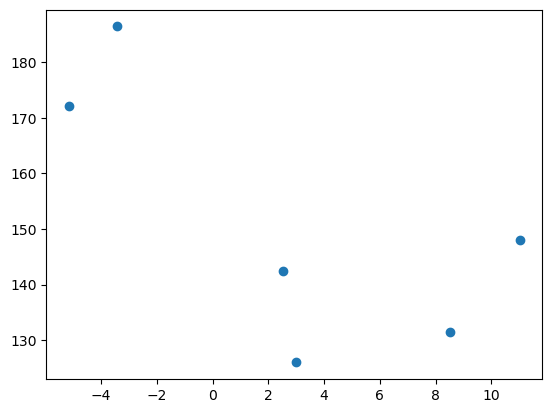

In [137]:
# To check constant variance
plt.scatter(error, y_pred_test)